1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

2. Load Dataset

In [8]:
df = pd.read_csv("../data/European_Bank.csv")
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


3. Basic Validation

In [10]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

churn distribution:

In [11]:
df["Exited"].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

ENGAGEMENT ANALYSIS

4. Churn by Activity

In [12]:
engagement_churn = df.groupby("IsActiveMember")["Exited"].mean()
engagement_churn

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

Engagement Retention Ratio

In [13]:
inactive_churn = engagement_churn[0]
active_churn = engagement_churn[1]

engagement_retention_ratio = inactive_churn / active_churn
engagement_retention_ratio

np.float64(1.8817547064195856)

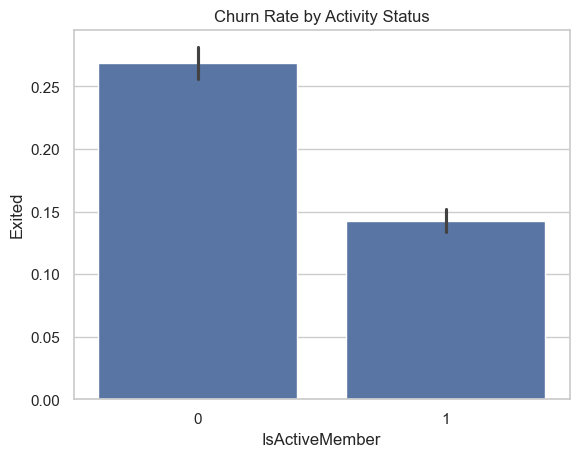

In [14]:
sns.barplot(x="IsActiveMember", y="Exited", data=df)
plt.title("Churn Rate by Activity Status")
plt.show()

PRODUCT UTILIZATION ANALYSIS

5. Churn by Number of Products

In [15]:
product_churn = df.groupby("NumOfProducts")["Exited"].mean()
product_churn

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

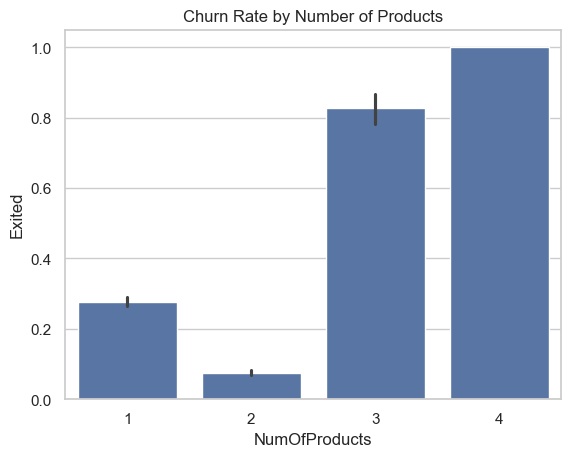

In [16]:
sns.barplot(x="NumOfProducts", y="Exited", data=df)
plt.title("Churn Rate by Number of Products")
plt.show()

6. Single vs Multi Product

In [17]:
df["MultiProduct"] = np.where(df["NumOfProducts"] >= 2, 1, 0)

df.groupby("MultiProduct")["Exited"].mean()

MultiProduct
0    0.277144
1    0.127746
Name: Exited, dtype: float64

PREMIUM RISK ANALYSIS

7. High Balance Threshold

In [18]:
balance_threshold = df["Balance"].quantile(0.75)

df["PremiumCustomer"] = np.where(df["Balance"] >= balance_threshold, 1, 0)

Inactive Premium Customers:

In [19]:
premium_inactive = df[(df["PremiumCustomer"] == 1) & (df["IsActiveMember"] == 0)]
premium_inactive["Exited"].mean()

np.float64(0.30473135525260625)

RELATIONSHIP STRENGTH INDEX (RSI)

8. Create RSI

In [20]:
df["Tenure_norm"] = df["Tenure"] / df["Tenure"].max()
df["Product_norm"] = df["NumOfProducts"] / df["NumOfProducts"].max()

df["RSI"] = (
    df["IsActiveMember"] * 0.3 +
    df["Product_norm"] * 0.3 +
    df["HasCrCard"] * 0.1 +
    df["Tenure_norm"] * 0.3
) * 100

9. Categorize RSI

In [21]:
def rsi_category(score):
    if score <= 40:
        return "Weak"
    elif score <= 70:
        return "Moderate"
    else:
        return "Strong"

df["RSI_Category"] = df["RSI"].apply(rsi_category)

Churn by RSI:

In [22]:
df.groupby("RSI_Category")["Exited"].mean()

RSI_Category
Moderate    0.176238
Strong      0.136332
Weak        0.271502
Name: Exited, dtype: float64

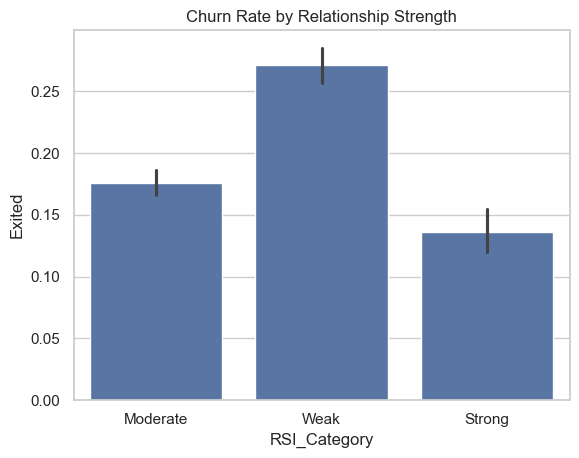

In [23]:
sns.barplot(x="RSI_Category", y="Exited", data=df)
plt.title("Churn Rate by Relationship Strength")
plt.show()